In [1]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel, wilcoxon
import torch
from torch import nn
from datasets.datasets import MRIDataset, STAREDataset

from helper_func.analyis_helper import clean_df, plot_boxplots, visualize, generate_batch_views, visualize_views, visualize_class_centroids, visualize_feats, prod_feats
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [7]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas



def display_image(color, label, b1, frames, class_id, ax):
    colored_out_mask = np.zeros((label.shape[1],label.shape[2] , 3))
    colored_out_mask[label[class_id,:,:,frames] == 1] = color
    ax.imshow(colored_out_mask)
    ax.add_patch(plt.Rectangle(b1[0], b1[2] , -b1[1], ls="--", ec="c", fc="none"))
    

    
def renormalize(arr):
    foreground = arr[arr != 0]
    min_val, max_val = np.min(foreground), np.max(foreground)

    scaled = (arr - min_val) / (max_val - min_val + 1e-8)
    scaled[arr == 0] = 0 

    return scaled

def vis_image(path):
    image_path = path
    imgs = np.load(image_path)
    imgs = np.delete(imgs, 1, axis=0)
    for i in range(imgs.shape[0]):
        imgs[i] = renormalize(imgs[i])
    imgs = np.transpose(imgs, (3, 1, 2,0))
    return imgs


def display_image_overlay(color, label, b1, frames, class_id, ax, title, image, alpha=0.4):
    C,H,W,T = label.shape
    m = (label[class_id, :, :, frames] > 0)

    # normalize image to 0..1 and make RGB
    img = image.astype(float)
    if img.ndim == 2:
        lo, hi = np.percentile(img, [1, 99])
        if hi > lo:
            img = np.clip((img - lo)/(hi - lo), 0, 1)
        img_rgb = np.repeat(img[..., None], 3, axis=2)
    else:
        if img.max() > 1.0:  # assume 0..255
            img = img / 255.0
        img_rgb = img

    # overlay color
    col = (np.array(color, float) / 255.0)
    overlay_rgb = np.zeros_like(img_rgb)
    overlay_rgb[m] = col

    # alpha map
    A = (m.astype(float) * alpha)[..., None]  # HxWx1

    # alpha blending: out = A*overlay + (1-A)*img
    comp = A*overlay_rgb + (1.0 - A)*img_rgb
    # comp = np.transpose(comp, (1, 0, 2))
    ax.imshow(comp, interpolation='nearest')
    # if title: ax.set_title(title)
    ax.axis('off')

def display_image_sides(color, label, b1, frames, class_id, ax, title, image, alpha=0.4):
    C,H,W,T = label.shape
    m = (label[class_id, :, 112,:] > 0)

    # normalize image to 0..1 and make RGB
    img = image.astype(float)
    if img.ndim == 2:
        lo, hi = np.percentile(img, [1, 99])
        if hi > lo:
            img = np.clip((img - lo)/(hi - lo), 0, 1)
        img_rgb = np.repeat(img[..., None], 3, axis=2)
    else:
        if img.max() > 1.0:  # assume 0..255
            img = img / 255.0
        img_rgb = img

    # overlay color
    col = (np.array(color, float) / 255.0)
    overlay_rgb = np.zeros_like(img_rgb)
    print(f'overlay_rgb shape {overlay_rgb.shape}, m shape {m.shape}')
    m = m.T
    overlay_rgb[m] = col
    # overlay_rgb = overlay_rgb.T
    # img_rgb = img_rgb.T

    # alpha map
    A = (m.astype(float) * alpha)[..., None]  # HxWx1

    # alpha blending: out = A*overlay + (1-A)*img
    comp = A*overlay_rgb + (1.0 - A)*img_rgb
    comp = np.transpose(comp, (1, 0, 2))
    ax.imshow(comp, interpolation='nearest')
    # if title: ax.set_title(title)
    ax.axis('off')

def display_image_sides2(color, label, b1, frames, class_id, ax, title, image, alpha=0.4):
    C,H,W,T = label.shape
    m = (label[class_id, 86, :,:] > 0)

    # normalize image to 0..1 and make RGB
    img = image.astype(float)
    if img.ndim == 2:
        lo, hi = np.percentile(img, [1, 99])
        if hi > lo:
            img = np.clip((img - lo)/(hi - lo), 0, 1)
        img_rgb = np.repeat(img[..., None], 3, axis=2)
    else:
        if img.max() > 1.0:  # assume 0..255
            img = img / 255.0
        img_rgb = img

    # overlay color
    col = (np.array(color, float) / 255.0)
    overlay_rgb = np.zeros_like(img_rgb)
    print(f'overlay_rgb shape {overlay_rgb.shape}, m shape {m.shape}')
    m = m.T
    overlay_rgb[m] = col
    # overlay_rgb = overlay_rgb.T
    # img_rgb = img_rgb.T

    # alpha map
    A = (m.astype(float) * alpha)[..., None]  # HxWx1

    # alpha blending: out = A*overlay + (1-A)*img
    comp = A*overlay_rgb + (1.0 - A)*img_rgb
    comp = np.transpose(comp, (1, 0, 2))

    ax.imshow(comp, interpolation='nearest')
    # if title: ax.set_title(title)
    ax.axis('off')

def display_image(color, label, b1, frames, class_id, ax, title):
    
    # print(f'here {label.shape}')
    colored_out_mask = np.zeros((label.shape[1],label.shape[2], 3 ))
    mask = label[class_id, :, :, frames] == 1
    colored_out_mask[mask] = np.array(color, dtype=np.uint8)
    ax.imshow(colored_out_mask)
    # ax.add_patch(plt.Rectangle(b1[0], b1[2] , -b1[1], ls="--", ec="c", fc="none"))
    ax.set_title(title)

def preprocess_bbox(bbox):
    print(bbox)
    x = int(bbox[0][0]) 
    y = int(bbox[0][3]) 
    w = int(bbox[0][2]) - int(bbox[0][0])
    h = int(bbox[0][3]) - int(bbox[0][1])
    return (x,y) , h, w

def fig2img(fig):
    canvas = FigureCanvas(fig)  # Attach the Agg backend
    fig.set_canvas(canvas)      # Set the canvas to the figure
    canvas.draw()
    
    # Get the RGB buffer from the figure
    buf = canvas.buffer_rgba()  # Use buffer_rgba() instead of tostring_rgb
    img = np.asarray(buf)[:, :, :3]  # Drop alpha channel
    return img

def visualize_3d(dataset, pred_path, title, path_img, pred_path2, pred_path3  ):
    colors = [
        [255, 0, 0],       
        [255, 255, 0],     
        [128, 0, 128],     
    ]
    # graph_num = len(pred_path)
    for i in range(len(dataset)):
        # try:
        
            fig, ax = plt.subplots(9, 4, figsize=(10,10), constrained_layout=False)
            # fig.subplots_adjust(wspace=0.02, hspace=0.12, left=0.02, right=0.98, top=0.9, bottom=0.02)

            # fig.suptitle(title)
            # print(len(ax))
            idx, img, label_name, box, points, frames, label = dataset[i]
            print(img)
            b1 = preprocess_bbox(bbox=box[0])
            # b2 = preprocess_bbox(bbox=box[1])
            # b3 = preprocess_bbox(bbox=box[2])
            b = [b1,b1, b1]
            
            read_path = os.path.join(pred_path, f'{img[:-8]}.npy')
            # print(read_path)
            pred = np.load(read_path)[1:]

            read_path2 = os.path.join(pred_path2, f'{img[:-8]}.npy')
            # print(read_path)
            pred2 = np.load(read_path2)[1:]

            
            read_path3 = os.path.join(pred_path3, f'{img[:-8]}.npy')
            print(f'pred2.shape {read_path3}')
            # print(read_path)
            pred3 = np.load(read_path3)[1:]
            # print(f'pred2.shape {pred_path4}')
            # read_path4 = os.path.join(pred_path4, f'{img[:-8]}.npy')
            # print(read_path)
            

            # pred4 = np.load(read_path4)[1:]
            # pred = np.transpose(pred, (3,0,1,2))
            # sides = label[:, , :, :]
            label = np.array(label[1:])

            print(f'label.shape {label.shape}')
            # label = np.transpose(label, (1,2,3,0))

            true_img_path = f'{path_img}/{img}'
            true_img = vis_image(true_img_path)

            # if pred_path2:
            #     read_path2 = os.path.join(pred_path2, img[:-8])
            #     loadpath2 = os.path.join(read_path2, os.listdir(read_path2)[0])
            #     pred2 = np.load(loadpath2)
            #     pred2 = np.transpose(pred2, (3,0,1,2))




            
            label_key = ['NCR','ED','ET']

            for i in range(3):
                print(true_img[frames].shape)
                display_image_overlay(colors[i], label, b[i],frames, i, ax[i,0], label_key[i], true_img[frames, :, :, 1])
                display_image_overlay(colors[i], pred, b[i], frames, i, ax[i,1], label_key[i], true_img[frames, :, :, 1])
                display_image_overlay(colors[i], pred2, b[i],frames, i, ax[i,2], label_key[i], true_img[frames, :, :, 1])
                display_image_overlay(colors[i], pred3, b[i], frames, i, ax[i,3], label_key[i], true_img[frames, :, :, 1])
                display_image_sides(colors[i], label, b[i],frames, i, ax[i+3,0], label_key[i], true_img[:, :, 112, 1])
                display_image_sides(colors[i], pred, b[i], frames, i, ax[i+3,1], label_key[i], true_img[:, :, 112, 1])
                display_image_sides(colors[i], pred2, b[i],frames, i, ax[i+3,2], label_key[i], true_img[:, :, 112, 1])
                display_image_sides(colors[i], pred3, b[i], frames, i, ax[i+3,3], label_key[i], true_img[:, :, 112, 1])
                display_image_sides2(colors[i], label, b[i],frames, i, ax[i+6,0], label_key[i], true_img[:, 86, :, 1])
                display_image_sides2(colors[i], pred, b[i], frames, i, ax[i+6,1], label_key[i], true_img[:, 86, :, 1])
                display_image_sides2(colors[i], pred2, b[i],frames, i, ax[i+6,2], label_key[i], true_img[:, 86, :, 1])
                display_image_sides2(colors[i], pred3, b[i], frames, i, ax[i+6,3], label_key[i], true_img[:, 86, :, 1])

                # if pred_path2:
                #     display_image(colors[i], pred2, b[i], frames, i, ax[i,2])
                #     display_image(colors[i], pred3, b[i], frames, i, ax[i,2])
                    # display_image(colors[i], pred4, b[i], frames, i, ax[i,2])


            # plt.legend(title='Legend')
            
            # plt.imshow(true_img[frames])
            
                
            plt.show()
        # except Exception as e:
        #     print(e)

In [8]:
tta_ent_lr5_paths =   "/scratch-second/TTA_results/val_ent_only_decoder_lr5/logs/BraTS_GLI/SSA_boxes.csv"
tta_ent_lr5_augs_paths =    "/scratch-second/TTA_results/val_ent_only_decoder_lr5_augs/logs/BraTS_GLI/SSA_boxes.csv"

In [12]:
tta_ent_lr5 =  pd.read_csv(tta_ent_lr5_paths)
tta_ent_lr5 = clean_df(tta_ent_lr5, True, 'brats')

target (p25 of row-mean): 0.5616537804404895
                       name  dice_NCR   dice_ED   dice_ET  hausdorff_NCR  \
29  BraTS-SSA-00117-000.npy  0.833348  0.522646  0.332184      44.698994   
14  BraTS-SSA-00051-000.npy  0.270694  0.849329  0.555291     104.580101   
0   BraTS-SSA-00007-000.npy  0.354372  0.663842  0.718972      52.583267   
5   BraTS-SSA-00015-000.npy  0.859739  0.634005  0.134796      46.400433   
37  BraTS-SSA-00141-000.npy  0.534652  0.509501  0.698778      11.224972   
35  BraTS-SSA-00133-000.npy  0.540807  0.569182  0.505811      10.049875   
1   BraTS-SSA-00008-000.npy  0.677826  0.641739  0.458019       7.017767   
10  BraTS-SSA-00041-000.npy  0.395941  0.716649  0.428318      26.419689   
43  BraTS-SSA-00220-000.npy  0.221686  0.600524  0.717719      32.341923   
22  BraTS-SSA-00080-000.npy  0.000000  0.718935  0.808643      68.550682   

    hausdorff_ED  hausdorff_ET  recall_NCR  recall_ED  recall_ET  \
29     62.801273     28.149603    0.757429   0.811

BraTS-SSA-00007-000-stk.npy
[[111.  70. 150. 118.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00007-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

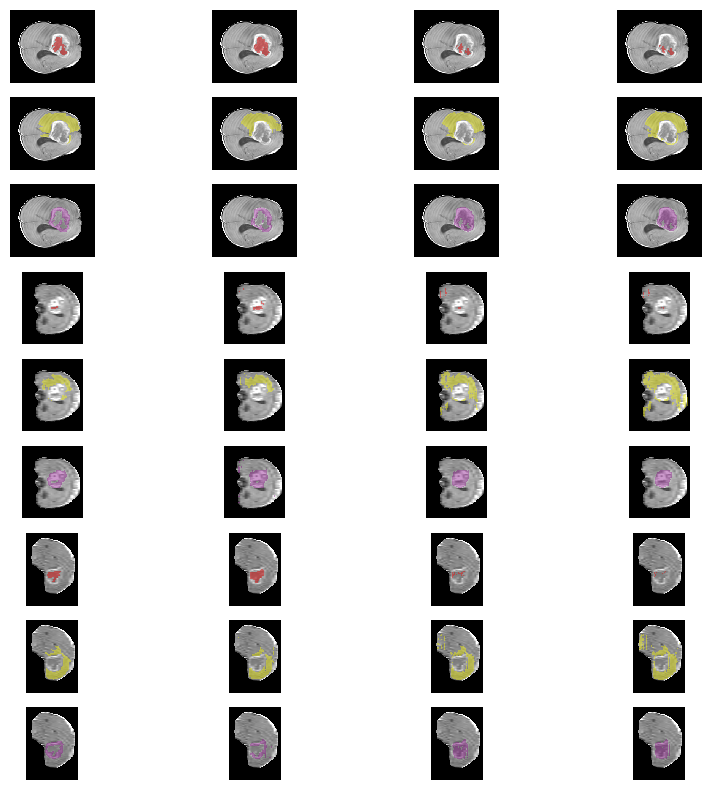

BraTS-SSA-00008-000-stk.npy
[[62. 56. 96. 90.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00008-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_r

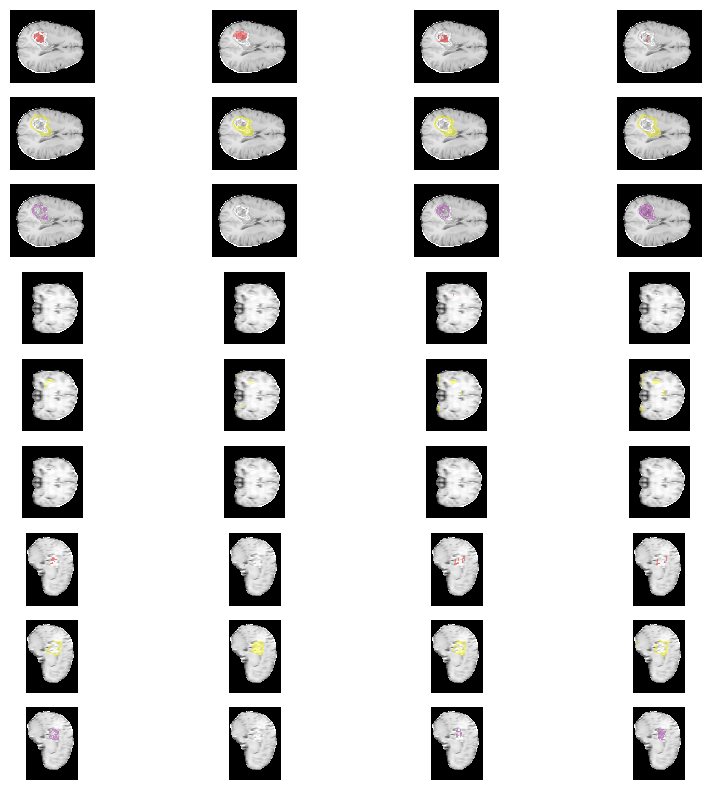

BraTS-SSA-00015-000-stk.npy
[[104.  65. 177. 115.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00015-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

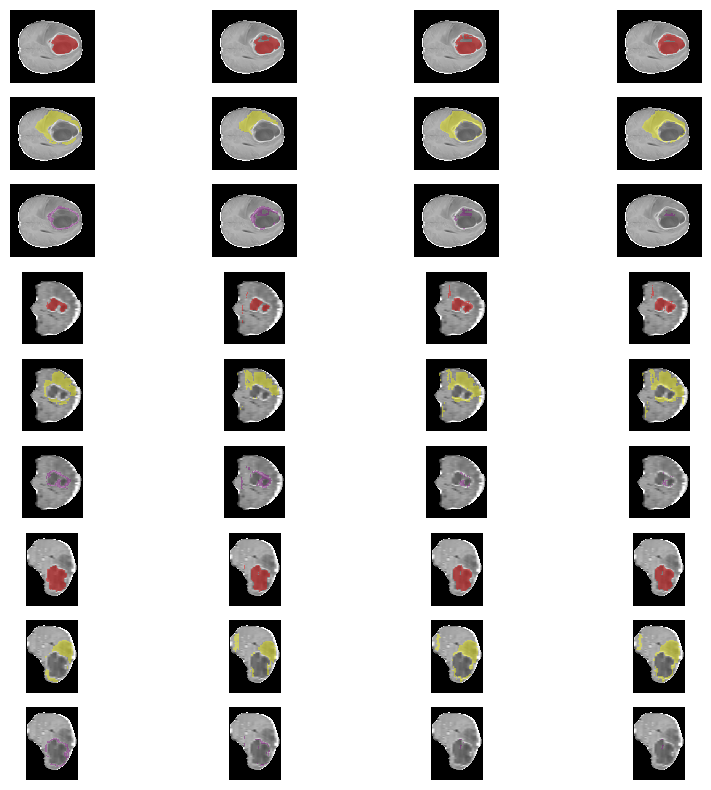

BraTS-SSA-00041-000-stk.npy
[[90. 90. 91. 92.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00041-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_r

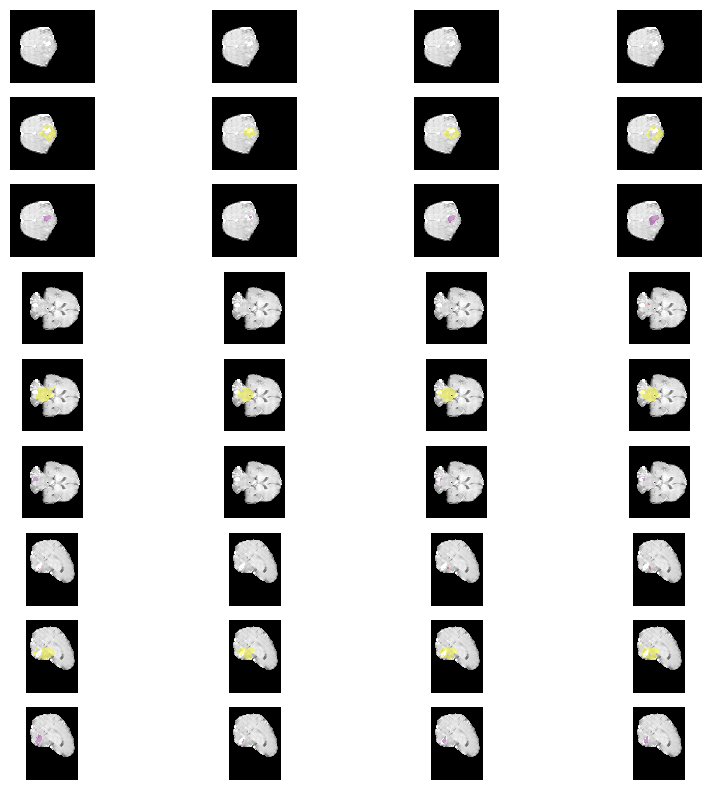

BraTS-SSA-00051-000-stk.npy
[[114.  72. 126.  81.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00051-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

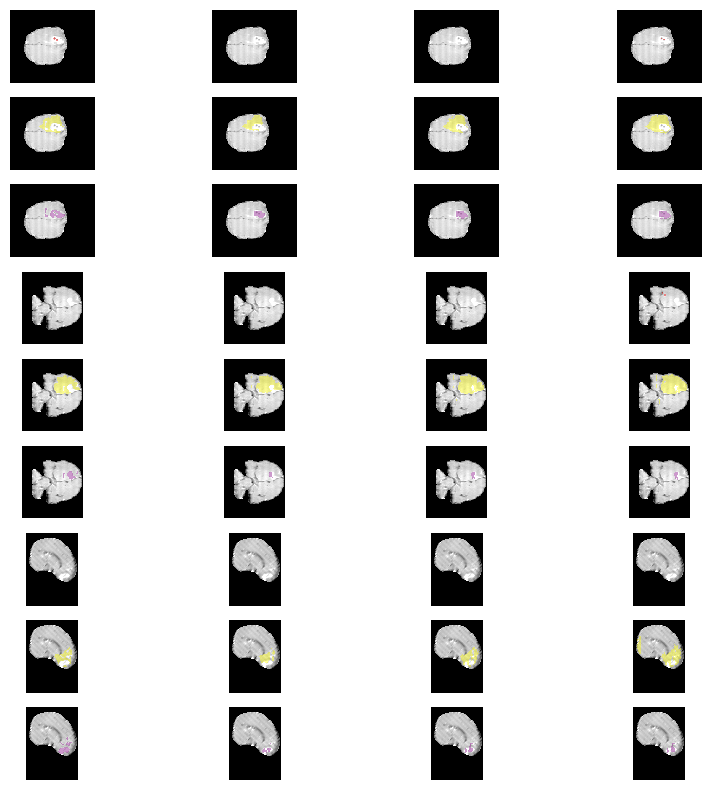

BraTS-SSA-00080-000-stk.npy
[[127. 108. 127. 108.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00080-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

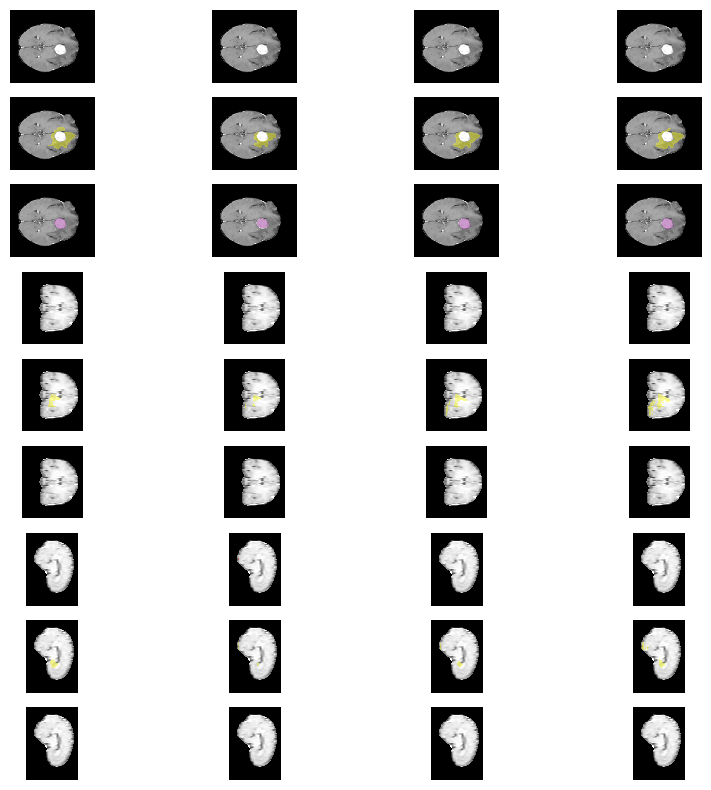

BraTS-SSA-00117-000-stk.npy
[[ 49.  62. 145. 163.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00117-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

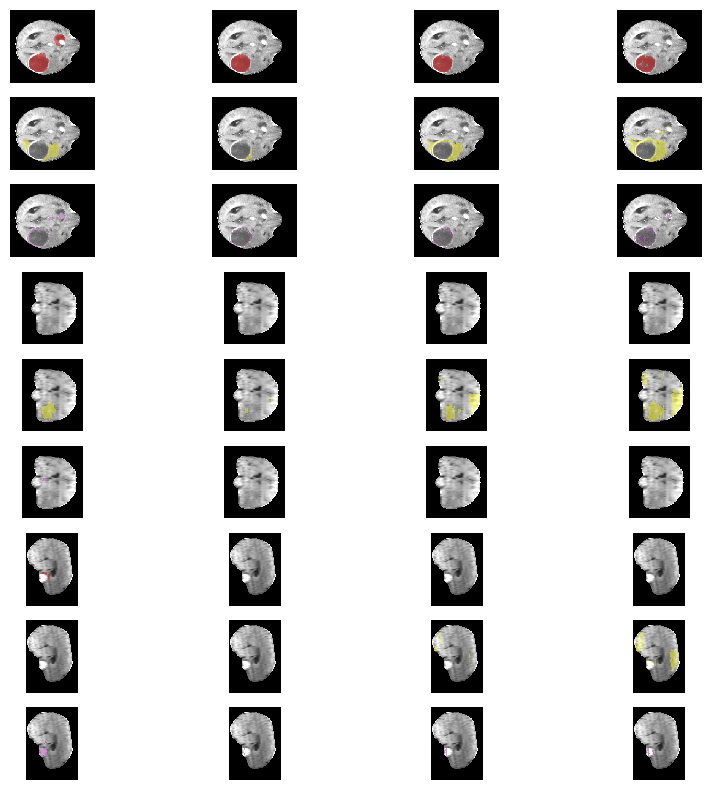

BraTS-SSA-00133-000-stk.npy
[[ 60. 103. 123. 142.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00133-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

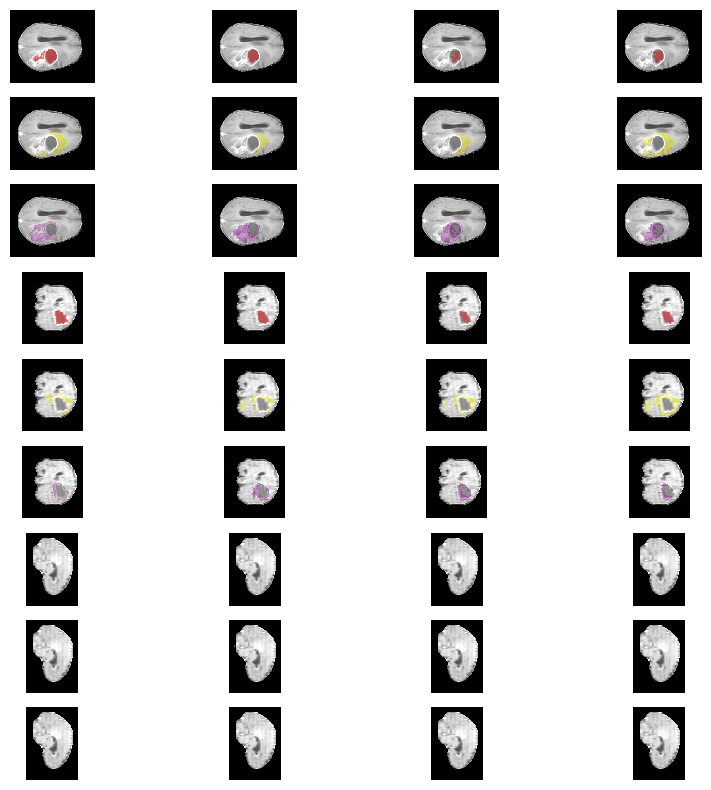

BraTS-SSA-00141-000-stk.npy
[[ 99.  58. 158. 105.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00141-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overl

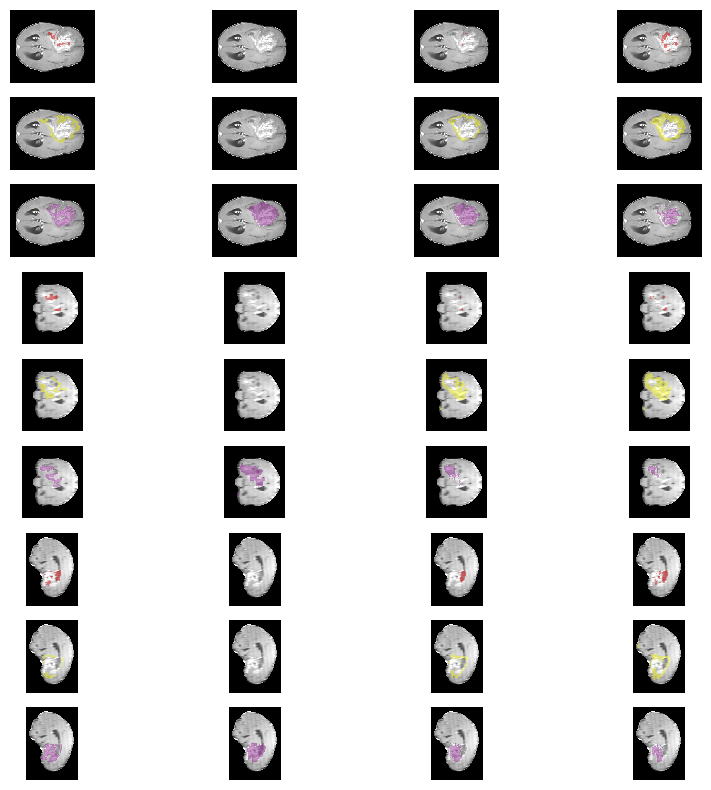

BraTS-SSA-00220-000-stk.npy
[[48. 44. 92. 70.]]
pred2.shape /scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00220-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_r

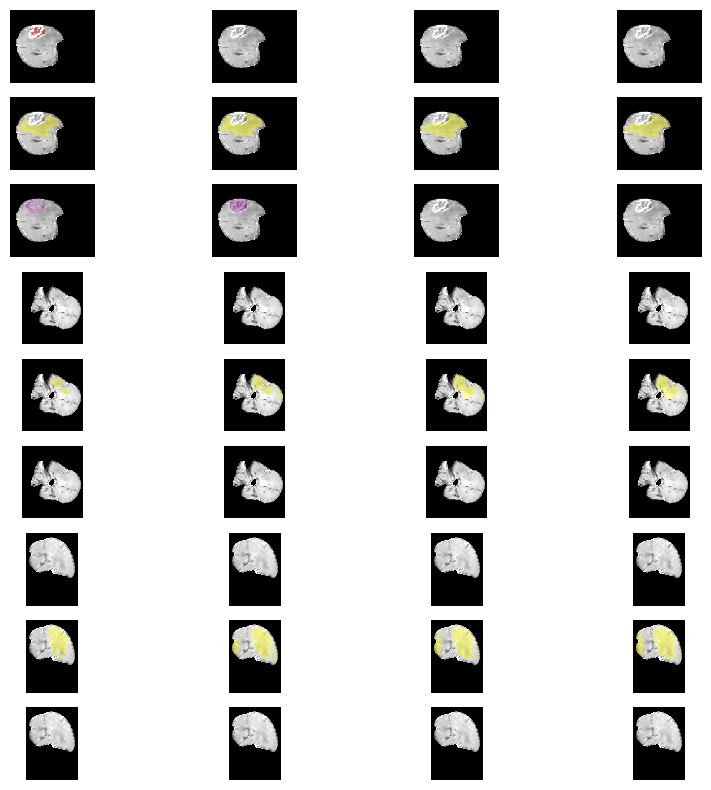

In [14]:
GLI_video_path = '/scratch-second/BraTS_SSA/Validation/images_UNN'
GLI_label_path = '/scratch-second/BraTS_SSA/Validation/labels_UNN'
GLI_pred_path = '/scratch-second/TTA_results/val_ent_only_decoder_lr4/logs/BraTS_GLI'
pred2 = '/scratch-second/TTA_results/val_ent_only_decoder_lr5/logs/BraTS_GLI'
pred3 = '/scratch-second/TTA_results/val_ent_only_decoder_lr6/logs/BraTS_GLI' 
cols = ["dice_ED", "dice_ET", "dice_NCR"]

# target (scalar): 25th percentile of per-row mean
target = tta_ent_lr5[cols].mean(axis=1).quantile(0.75)
print("target (p25 of row-mean):", target)

GLI_4 = (tta_ent_lr5
         .assign(_diff=(tta_ent_lr5[cols].mean(axis=1) - target).abs())
         .nsmallest(10, "_diff")
         .drop(columns="_diff"))

print(GLI_4)
GLI_worst_list = GLI_4.name.to_list()

GLI_worst_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_worst_list)
visualize_3d(GLI_worst_dataset, GLI_pred_path, 'GT Vs MedSAM2-BraTS-GLI', GLI_video_path, pred2,  pred3)

target (p25 of row-mean): 0.5616537804404895
                       name  dice_NCR   dice_ED   dice_ET  hausdorff_NCR  \
29  BraTS-SSA-00117-000.npy  0.833348  0.522646  0.332184      44.698994   
14  BraTS-SSA-00051-000.npy  0.270694  0.849329  0.555291     104.580101   
0   BraTS-SSA-00007-000.npy  0.354372  0.663842  0.718972      52.583267   
5   BraTS-SSA-00015-000.npy  0.859739  0.634005  0.134796      46.400433   
37  BraTS-SSA-00141-000.npy  0.534652  0.509501  0.698778      11.224972   
35  BraTS-SSA-00133-000.npy  0.540807  0.569182  0.505811      10.049875   
1   BraTS-SSA-00008-000.npy  0.677826  0.641739  0.458019       7.017767   
10  BraTS-SSA-00041-000.npy  0.395941  0.716649  0.428318      26.419689   
43  BraTS-SSA-00220-000.npy  0.221686  0.600524  0.717719      32.341923   
22  BraTS-SSA-00080-000.npy  0.000000  0.718935  0.808643      68.550682   

    hausdorff_ED  hausdorff_ET  recall_NCR  recall_ED  recall_ET  \
29     62.801273     28.149603    0.757429   0.811

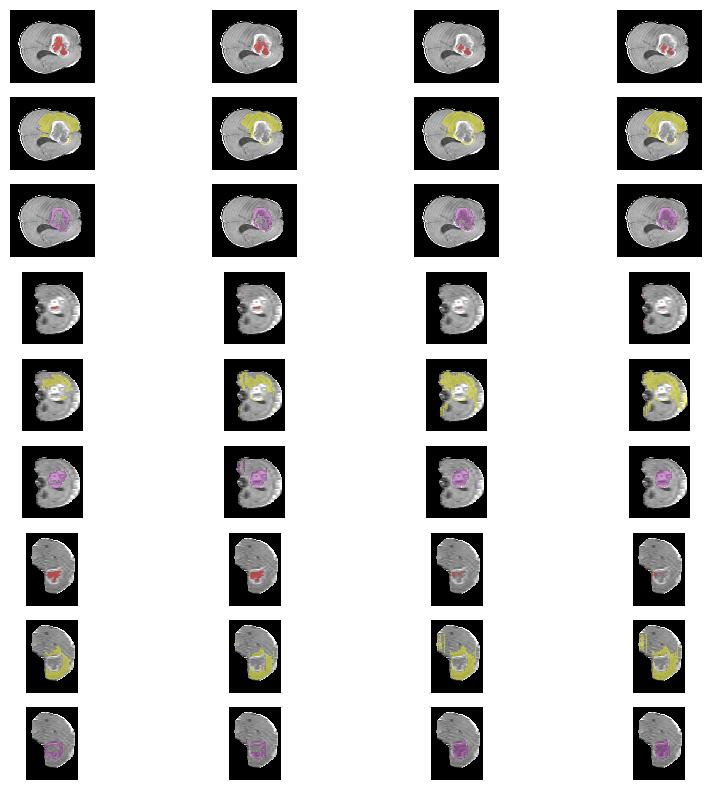

BraTS-SSA-00008-000-stk.npy
[[62. 56. 96. 90.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00008-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rg

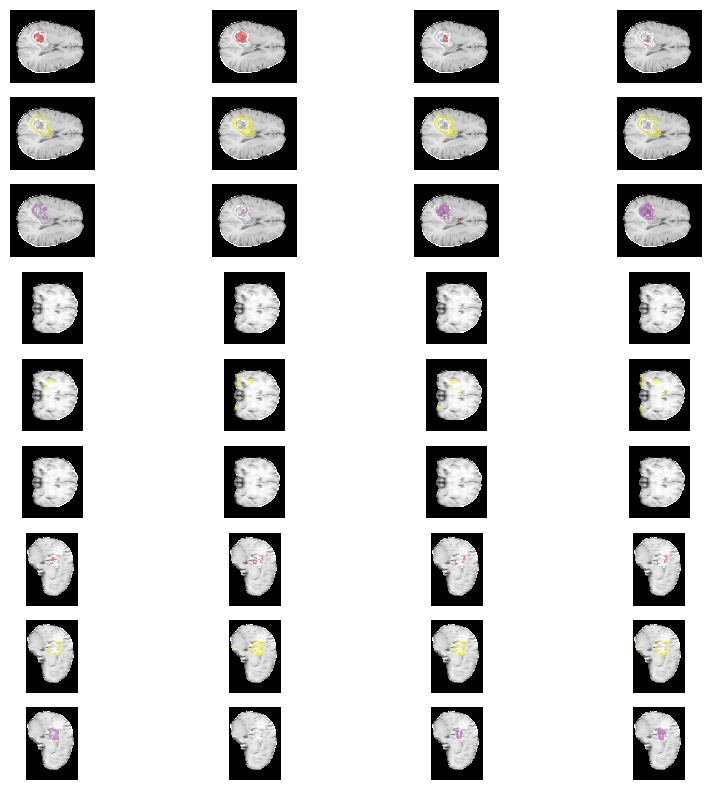

BraTS-SSA-00015-000-stk.npy
[[104.  65. 177. 115.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00015-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

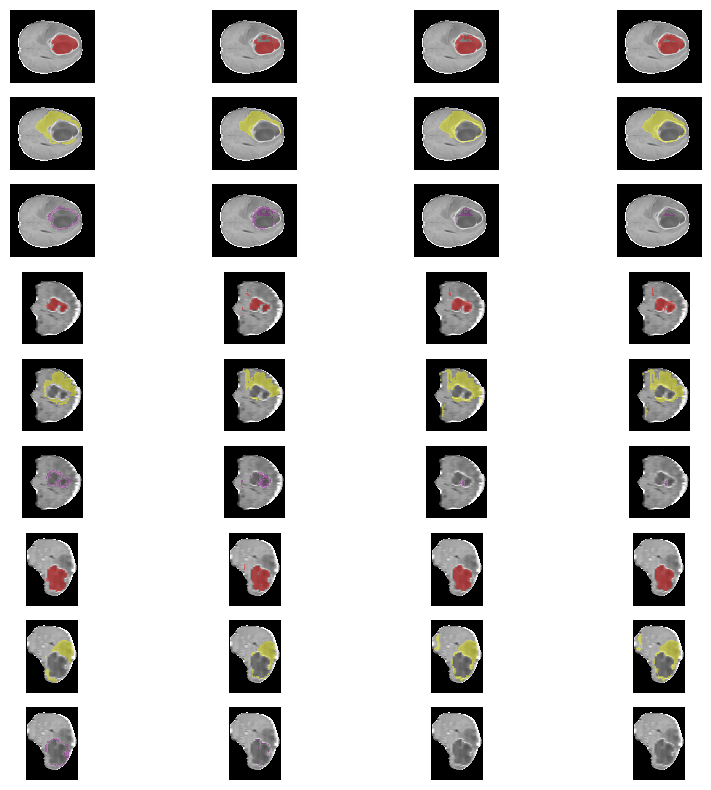

BraTS-SSA-00041-000-stk.npy
[[90. 90. 91. 92.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00041-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rg

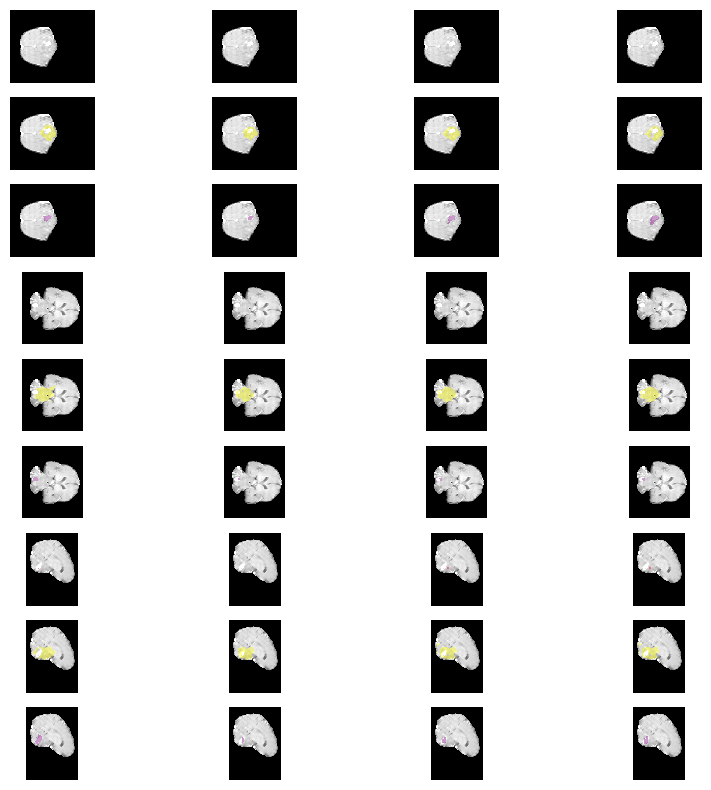

BraTS-SSA-00051-000-stk.npy
[[114.  72. 126.  81.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00051-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

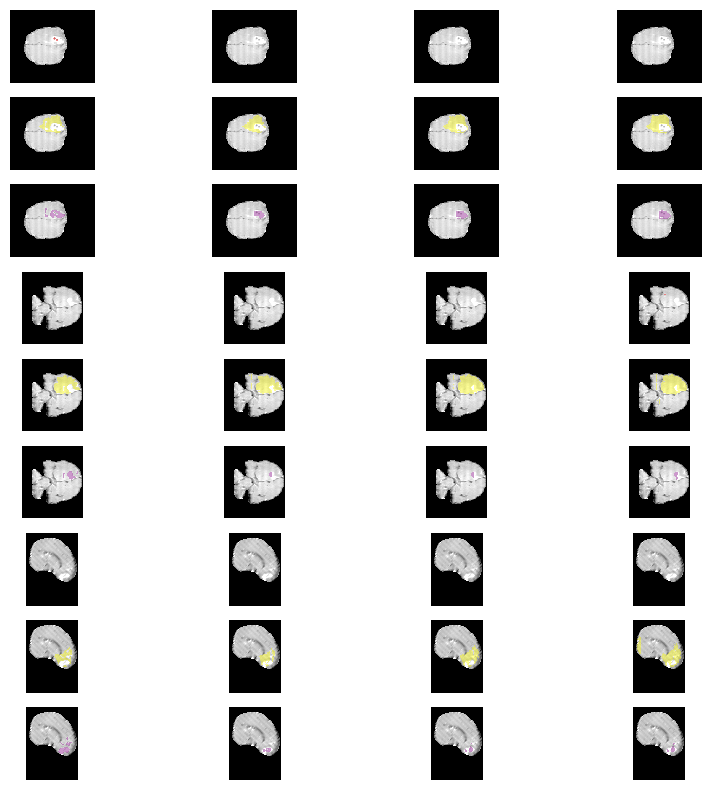

BraTS-SSA-00080-000-stk.npy
[[127. 108. 127. 108.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00080-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

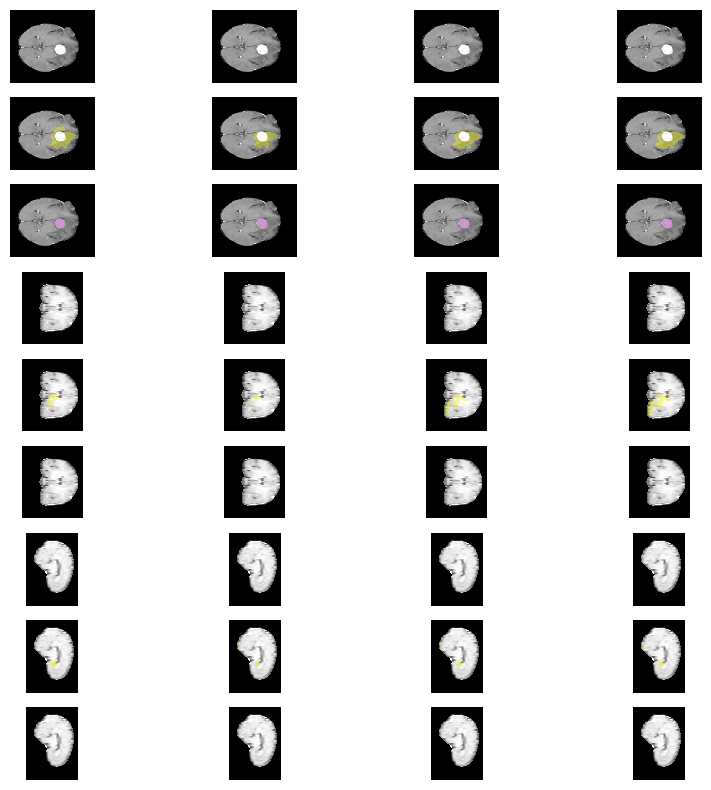

BraTS-SSA-00117-000-stk.npy
[[ 49.  62. 145. 163.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00117-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

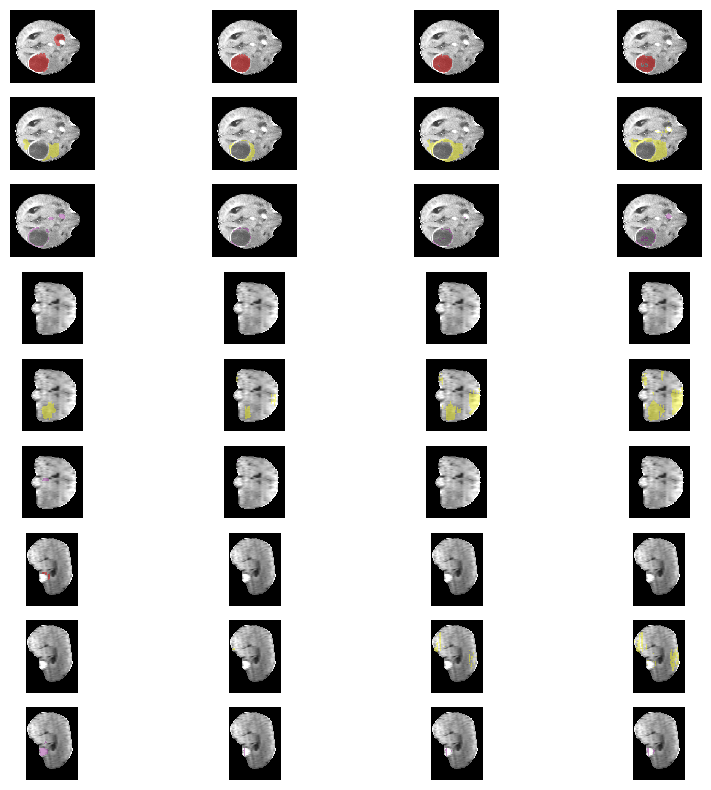

BraTS-SSA-00133-000-stk.npy
[[ 60. 103. 123. 142.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00133-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

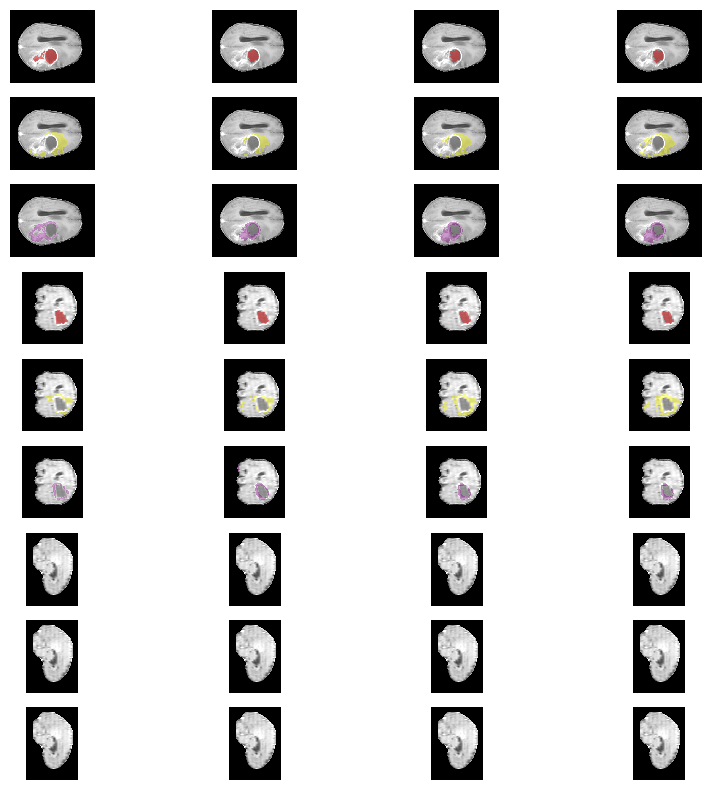

BraTS-SSA-00141-000-stk.npy
[[ 99.  58. 158. 105.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00141-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overla

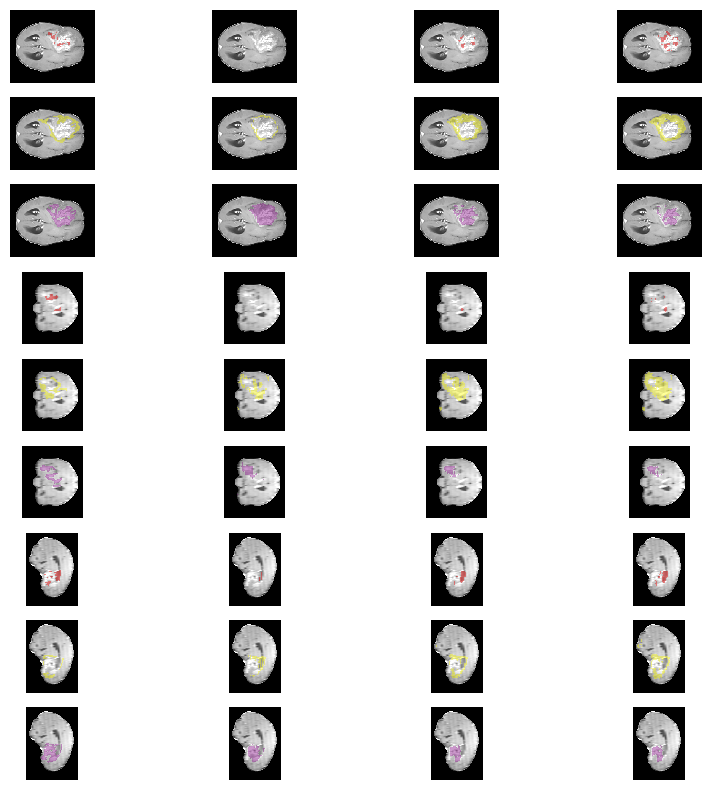

BraTS-SSA-00220-000-stk.npy
[[48. 44. 92. 70.]]
pred2.shape /scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI/BraTS-SSA-00220-000.npy
label.shape (3, 192, 224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
(192, 224, 3)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 192, 3), m shape (192, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rgb shape (160, 224, 3), m shape (224, 160)
overlay_rg

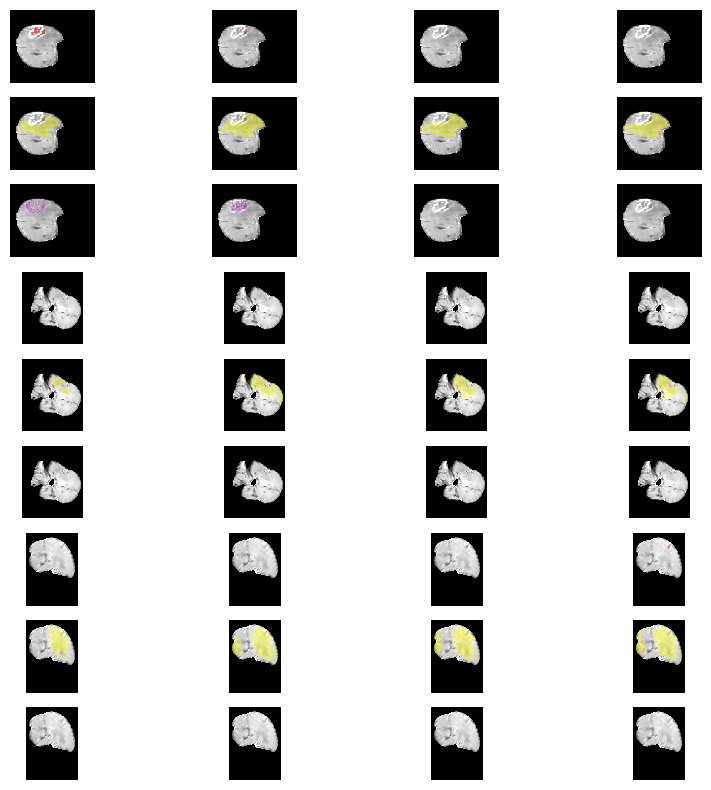

In [15]:
GLI_video_path = '/scratch-second/BraTS_SSA/Validation/images_UNN'
GLI_label_path = '/scratch-second/BraTS_SSA/Validation/labels_UNN'
GLI_pred_path = '/scratch-second/TTA_results/val_ent_sup_decoder_lr4/logs/BraTS_GLI'
pred2 = '/scratch-second/TTA_results/val_ent_sup_decoder_lr5/logs/BraTS_GLI'
pred3 = '/scratch-second/TTA_results/val_ent_sup_decoder_lr6/logs/BraTS_GLI' 
cols = ["dice_ED", "dice_ET", "dice_NCR"]

# target (scalar): 25th percentile of per-row mean
target = tta_ent_lr5[cols].mean(axis=1).quantile(0.75)
print("target (p25 of row-mean):", target)

GLI_4 = (tta_ent_lr5
         .assign(_diff=(tta_ent_lr5[cols].mean(axis=1) - target).abs())
         .nsmallest(10, "_diff")
         .drop(columns="_diff"))

print(GLI_4)
GLI_worst_list = GLI_4.name.to_list()

GLI_worst_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_worst_list)
visualize_3d(GLI_worst_dataset, GLI_pred_path, 'GT Vs MedSAM2-BraTS-GLI', GLI_video_path, pred2,  pred3)